# 05 — Backtest & Calibration

Runs the value-bet backtest on the held-out season only (never the training seasons) — this is a sanity check, not a target to chase. A strongly positive ROI is a red flag for overfitting/leakage far more often than a genuine edge.

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

from pl_predictor.features.build import build_training_frame
from pl_predictor.models.manifest import chronological_split, load_models
from pl_predictor.evaluate import backtest, calibration

df, feature_cols = build_training_frame()
train_df, val_df = chronological_split(df)
models = load_models()

## Calibration vs. the market

In [2]:
model_metrics = calibration.model_calibration(models['scoreline'], val_df)
bookmaker_metrics = calibration.bookmaker_calibration(val_df)
naive_metrics = calibration.naive_favourite_baseline(val_df)

import pandas as pd
pd.DataFrame([model_metrics, bookmaker_metrics, naive_metrics], index=['model', 'bookmaker', 'naive'])

,rps,brier,ignorance,n_matches
model,0.211741,0.622835,1.494075,380
bookmaker,0.205994,0.612337,1.470623,380
naive,0.227903,0.655147,NaN,380


## Value-bet backtest

In [3]:
start, end = str(val_df['date'].min().date()), str(val_df['date'].max().date())
results = backtest.run_value_bet_backtest(val_df, models['scoreline'], start, end)
results

  0%|          | 0/114 [00:00<?, ?it/s]

{'Total Bets': 137,
 'Successful Bets': 33,
 'Successful Bet %': 24.087591240875913,
 'Max Bankroll': np.float64(108.61),
 'Min Bankroll': np.float64(63.69999999999999),
 'Profit': -36.30000000000001,
 'ROI': -36.30000000000001}

  0%|          | 0/114 [00:00<?, ?it/s]

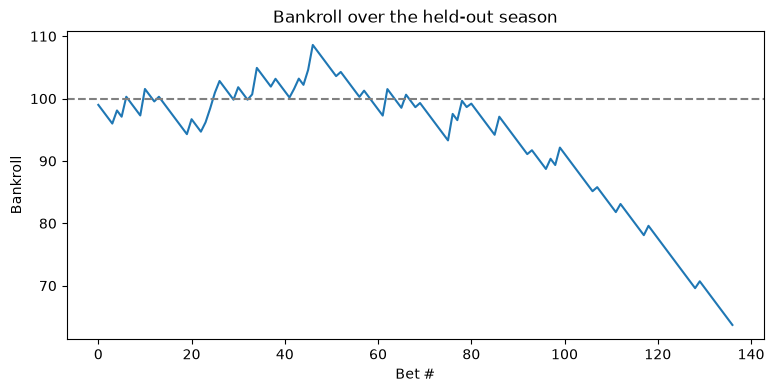

In [4]:
import matplotlib.pyplot as plt

bt = backtest.build_value_bet_backtest(val_df, models['scoreline'], start, end)
plt.figure(figsize=(9, 4))
plt.plot(bt.account.tracker)
plt.axhline(100.0, color='gray', linestyle='--')
plt.title('Bankroll over the held-out season'); plt.xlabel('Bet #'); plt.ylabel('Bankroll')
plt.show()